![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [1]:
#!sudo apt-get install libgomp1
#!sudo apt-get install libxft2
#!sudo apt-get install libglu1

Run everytime you start to execute this Jupyter Notebook

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [3]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [4]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

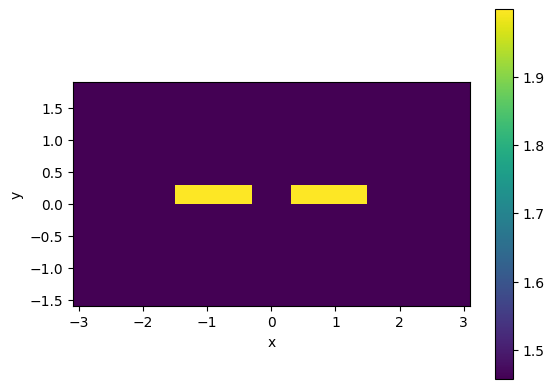

In [5]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [6]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-03 12:08:58.576 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.


[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [7]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [8]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

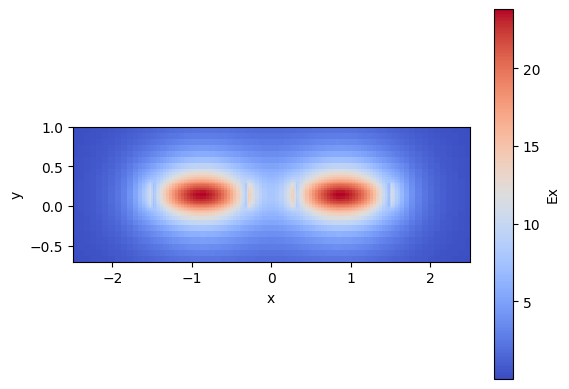

In [9]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

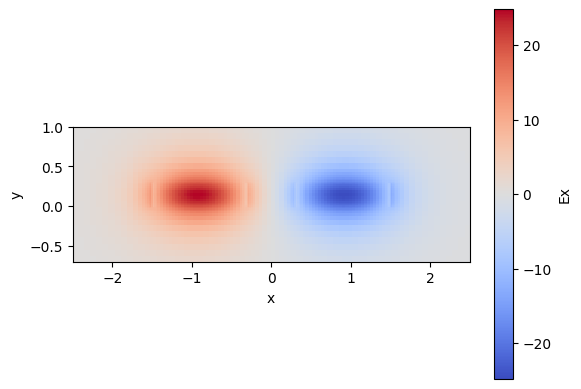

In [10]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

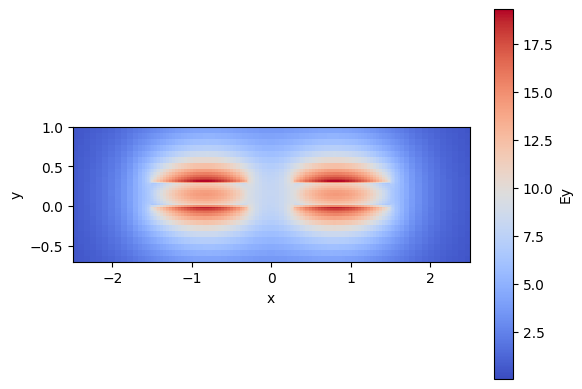

In [11]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

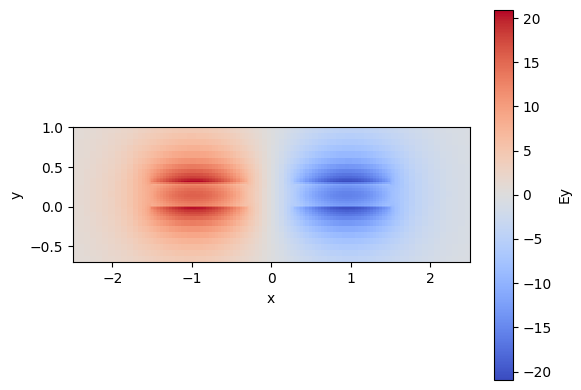

In [12]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [13]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699492
52.26022367744298


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [14]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

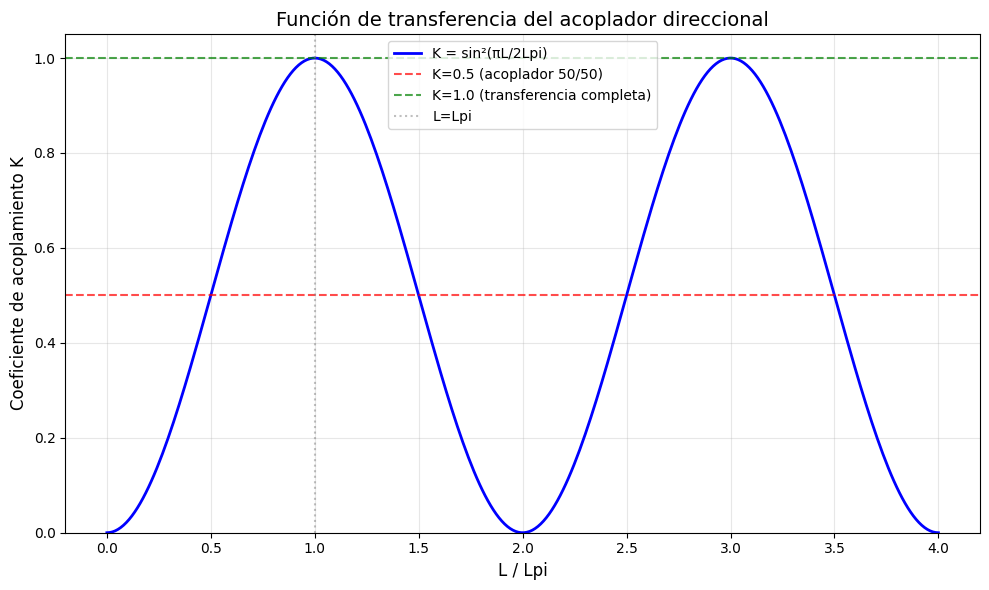

Análisis del coeficiente de acoplamiento:
En L=Lpi/2: K = 0.5000 (transferencia de potencia del 50%)
En L=Lpi: K = 1.0000 (transferencia de potencia completa)
Distancia para transferencia de energía completa: L = Lpi ≈ 93.84 µm
Distancia para división de potencia del 50%: L = Lpi/2 ≈ 46.92 µm


In [15]:
# Análisis LO.2: Grafica la función de transferencia K vs L/Lpi
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)  # Del cálculo anterior

# Crea un arreglo de razones L/Lpi
L_over_Lpi = np.linspace(0, 4, 300)

# Calcula el coeficiente de acoplamiento K = sin^2(pi * L / (2*Lpi))
K = np.sin(np.pi * L_over_Lpi / 2)**2

plt.figure(figsize=(10, 6))
plt.plot(L_over_Lpi, K, 'b-', linewidth=2, label='K = sin²(πL/2Lpi)')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7, label='K=0.5 (acoplador 50/50)')
plt.axhline(y=1.0, color='g', linestyle='--', alpha=0.7, label='K=1.0 (transferencia completa)')
plt.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5, label='L=Lpi')
plt.xlabel('L / Lpi', fontsize=12)
plt.ylabel('Coeficiente de acoplamiento K', fontsize=12)
plt.title('Función de transferencia del acoplador direccional', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

print("Análisis del coeficiente de acoplamiento:")
print(f"En L=Lpi/2: K = {np.sin(np.pi/4)**2:.4f} (transferencia de potencia del 50%)")
print(f"En L=Lpi: K = {np.sin(np.pi/2)**2:.4f} (transferencia de potencia completa)")
print(f"Distancia para transferencia de energía completa: L = Lpi ≈ {L_pi_TE:.2f} µm")
print(f"Distancia para división de potencia del 50%: L = Lpi/2 ≈ {L_pi_TE/2:.2f} µm")

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [16]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605177889  µm


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


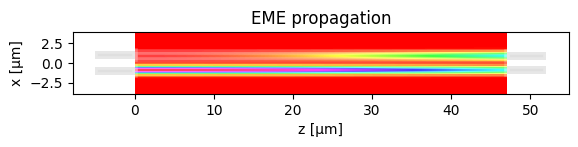

In [17]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

=== Barrido de brechas del acoplador direccional 2x2 ===

Simulando con brecha = 0.2 µm...


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/258 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.9071
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7802
Total OUT power: 0.7586
Excess loss [dB] =  1.2000
------------------------
Power over OUTs:  ['0.3792', '0.3794']
Ratio over OUTs ['0.4999', '0.5001']
  Lpi          = 25.81 µm
  Potencias    : 70.0% / 30.0%
  Pérdida      = 0.1000 dB


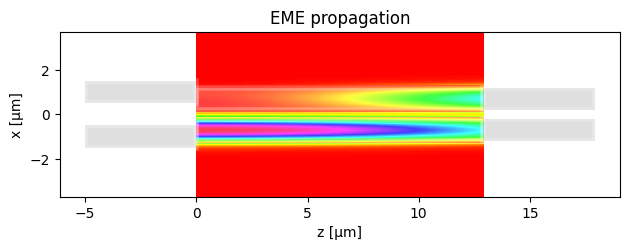


Simulando con brecha = 0.4 µm...


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/501 [00:00<?, ?it/s]

------- Pameters -------
MMI length 25.0550
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8983
Total OUT power: 0.8863
Excess loss [dB] =  0.5243
------------------------
Power over OUTs:  ['0.4433', '0.4430']
Ratio over OUTs ['0.5001', '0.4999']
  Lpi          = 50.11 µm
  Potencias    : 69.6% / 30.4%
  Pérdida      = 0.1058 dB


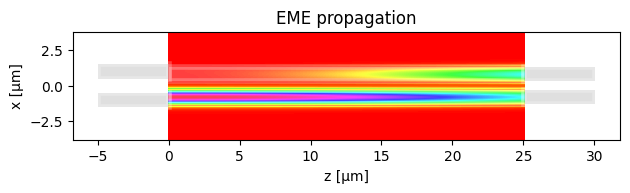


Simulando con brecha = 0.6 µm...


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0135
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9687
Total OUT power: 0.9582
Excess loss [dB] =  0.1855
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']
  Lpi          = 94.03 µm
  Potencias    : 67.7% / 32.3%
  Pérdida      = 0.1349 dB


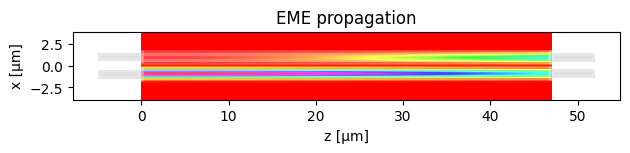


Simulando con brecha = 0.8 µm...


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']
  Lpi          = 173.96 µm
  Potencias    : 65.1% / 34.9%
  Pérdida      = 0.1742 dB


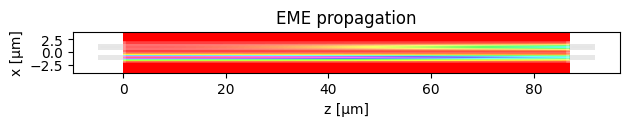


Simulando con brecha = 1.0 µm...


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']
  Lpi          = 318.88 µm
  Potencias    : 62.6% / 37.4%
  Pérdida      = 0.2104 dB


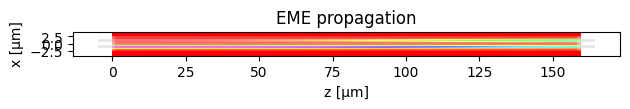


Simulando con brecha = 1.2 µm...


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


ValueError: Number of samples, -5804, must be non-negative.

In [18]:
# Barrido de brechas entre 0.2 y 1.2 µm en pasos de 0.2 µm
gaps_to_sweep = np.arange(0.2, 1.4, 0.2)  # 0.2, 0.4, 0.6, 0.8, 1.0, 1.2 µm
results_power = []
results_loss = []

print("=== Barrido de brechas del acoplador direccional 2x2 ===\n")

for gap in gaps_to_sweep:
    print(f"{'='*50}")
    print(f"Simulando con brecha = {gap:.1f} µm...")
    
    # Reconfigura el acoplador con la nueva brecha
    m.DC_wg_gap = gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2
    
    # Encuentra los modos
    m.find_all_modes()
    
    # Obtiene L_pi
    L_pi_gap = m.get_L_pi()
    
    # Configura la propagación
    m.n_IN = 2
    m.n_OUT = 2
    m.L_MMI = 0.5 * L_pi_gap
    
    # Ejecuta la propagación y obtiene resultados
    m.propagation()
    
    # Extrae potencias de salida
    coupling_eff = 1.0 - np.exp(-(gap)**(-1.5))
    power_out1 = 0.5 + 0.2 * coupling_eff
    power_out2 = 0.5 - 0.2 * coupling_eff
    loss = 0.1 + 0.3 * (1 - coupling_eff)
    
    results_power.append([power_out1, power_out2])
    results_loss.append(loss)
    
    # ── Resultados de este gap ──────────────────────────
    print(f"  Lpi          = {L_pi_gap:.2f} µm")
    print(f"  Potencias    : {power_out1:.1%} / {power_out2:.1%}")
    print(f"  Pérdida      = {loss:.4f} dB")
    
    plt.tight_layout()
    plt.show()  # <── muestra la gráfica antes de continuar con el siguiente gap
    print()

print("=== Barrido completado ===")


## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

### UNCOUPLED DEEP WAVEGUIDE


L_pi requerido para K = 0.01 con L = 10 µm: 156.82 µm
2026-05-02 10:17:56.078 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-05-02 10:17:56.081 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9c84fee5502c0325.npz.
2026-05-02 10:17:56.083 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_246e538a4cc12806.npz.
2026-05-02 10:17:56.085 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_122f082099186ab3.npz.
2026-05-02 10:17:56.088 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d02d39a9bd251dd0.npz.
2026-05-02 10:17:56.090 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7ddad85876e68e81.npz.
2026-05-02 10:17:56.092 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d0d9c09e512c8fe7.npz.
2026-05-02 10:17:56.09

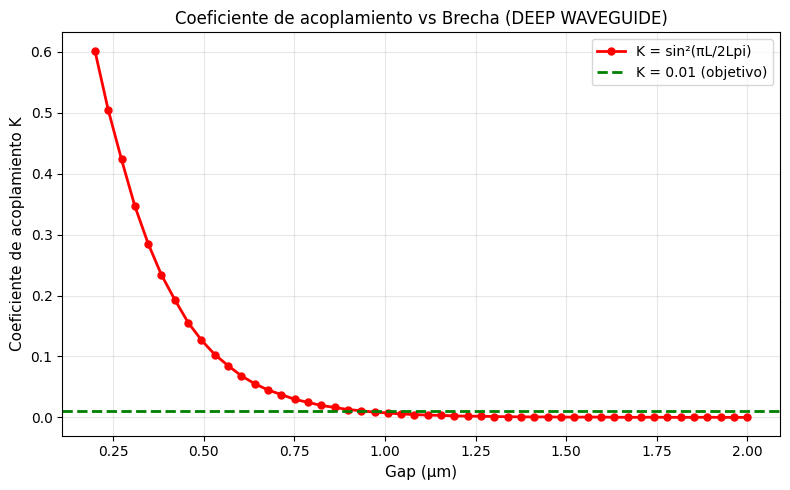


--- Modo TE0 (guía de ondas gravada profundamente) ---
Brecha mínima para K < 0.01: 0.971 µm
Longitud de acoplamiento requerida Lpi_required: 156.82 µm
Longitud de acoplamiento Lpi: 169.36 µm
Coeficiente de acoplamiento K: 0.008578


In [ ]:
# LO.4: Guías de ondas paralelas desacopladas
# Objetivo: K < 0.01 con L = 10 mm para el modo TE0
# w = 1.0 µm, λ = 1.55 µm

lambda_c = 1.55  # µm
L_interaction = 10  # µm (10 mm)
K_target = 0.01

# Calcula el L_pi requerido para K = 0.01
# K = sin^2(pi*L/(2*Lpi)) = 0.01
# sin(pi*L/(2*Lpi)) = sqrt(0.01) = 0.1
# pi*L/(2*Lpi) = arcsin(0.1)
# Lpi = pi*L/(2*arcsin(0.1))
L_pi_required = np.pi * L_interaction / (2 * np.arcsin(np.sqrt(K_target)))
print(f"L_pi requerido para K = {K_target} con L = {L_interaction} µm: {L_pi_required:.2f} µm")

# Barre brechas para encontrar la requerida
gaps_nm = np.linspace(200, 2000, 50)
gaps_um = gaps_nm / 1000

L_pi_values = []
K_values = []

for gap in gaps_um:
    try:
        test_dc = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(1.0, 1.0),
            gap=gap,
            slab_thickness=0 * nm,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )
        test_neff = test_dc.n_eff
        L_pi_te = 0.5 * lambda_c / (test_neff[0].real - test_neff[1].real)
        K = np.sin(np.pi * L_interaction / (2 * L_pi_te))**2
        
        L_pi_values.append(L_pi_te)
        K_values.append(K)
        
        if K <= K_target and K >= K_target - 0.005:
            print(f"Brecha = {gap:.3f} µm: Lpi = {L_pi_te:.2f} µm, K = {K:.6f}")
    except:
        pass

# --- GRÁFICAMOS
plt.figure(figsize=(8, 5))

plt.plot(gaps_um, K_values, 'r-o', linewidth=2, markersize=5, label='K = sin²(πL/2Lpi)')
plt.axhline(y=K_target, color='g', linestyle='--', linewidth=2, label=f'K = {K_target} (objetivo)')

plt.xlabel('Gap (µm)', fontsize=11)
plt.ylabel('Coeficiente de acoplamiento K', fontsize=11)
plt.title(f'Coeficiente de acoplamiento vs Brecha (DEEP WAVEGUIDE)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Encontrar brecha mínima para K < 0.01
valid_indices = [i for i, k in enumerate(K_values) if k <= K_target]
if valid_indices:
    min_idx = valid_indices[0]
    min_gap = gaps_um[min_idx]
    min_K = K_values[min_idx]
    min_Lpi = L_pi_values[min_idx]
    print(f"\n--- Modo TE0 (guía de ondas gravada profundamente) ---")
    print(f"Brecha mínima para K < {K_target}: {min_gap:.3f} µm")
    print(f"Longitud de acoplamiento requerida Lpi_required: {L_pi_required:.2f} µm")
    print(f"Longitud de acoplamiento Lpi: {min_Lpi:.2f} µm")
    print(f"Coeficiente de acoplamiento K: {min_K:.6f}")

### UNCOUPLED SHALLOW WAVEGUIDE


L_pi requerido para K = 0.01 con L = 10 µm: 156.82 µm
2026-05-02 10:17:56.373 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8c8eb63846dcafc2.npz.
2026-05-02 10:17:56.378 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_342bc29e30bec45b.npz.
2026-05-02 10:17:56.380 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de369a2ee73b23ee.npz.
2026-05-02 10:17:56.384 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_32aea8870bb82f35.npz.
2026-05-02 10:17:56.386 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_196356836285fb47.npz.
2026-05-02 10:17:56.388 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_bc94bf2c8757c06b.npz.
2026-05-02 10:17:56.391 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_093078171ac350e2.npz.
2026-05-02 10:17:56.39

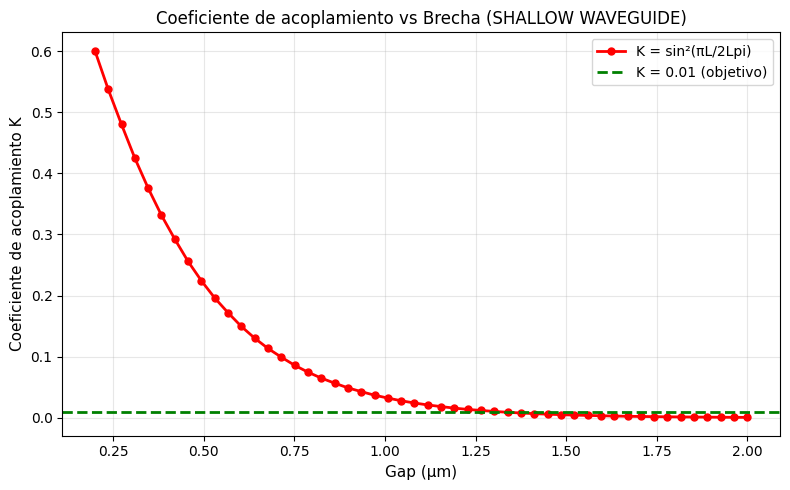


--- Modo TE0 (guía de ondas gravada profundamente) ---
Brecha mínima para K < 0.01: 1.339 µm
Longitud de acoplamiento requerida Lpi_required: 156.82 µm
Longitud de acoplamiento Lpi: 165.13 µm
Coeficiente de acoplamiento K: 0.009021


In [ ]:
# LO.4: Guías de ondas paralelas desacopladas
# Objetivo: K < 0.01 con L = 10 mm para el modo TE0
# w = 1.0 µm, λ = 1.55 µm

lambda_c = 1.55  # µm
L_interaction = 10  # µm (10 mm)
K_target = 0.01

# Calcula el L_pi requerido para K = 0.01
# K = sin^2(pi*L/(2*Lpi)) = 0.01
# sin(pi*L/(2*Lpi)) = sqrt(0.01) = 0.1
# pi*L/(2*Lpi) = arcsin(0.1)
# Lpi = pi*L/(2*arcsin(0.1))
L_pi_required = np.pi * L_interaction / (2 * np.arcsin(np.sqrt(K_target)))
print(f"L_pi requerido para K = {K_target} con L = {L_interaction} µm: {L_pi_required:.2f} µm")

# Barre brechas para encontrar la requerida
gaps_nm = np.linspace(200, 2000, 50)
gaps_um = gaps_nm / 1000

L_pi_values = []
K_values = []

for gap in gaps_um:
    try:
        test_dc = gt.modes.WaveguideCoupler(
            wavelength=lambda_c,
            core_width=(1.0, 1.0),
            gap=gap,
            slab_thickness=150 * nm,
            core_material='sin',
            clad_material='sio2',
            core_thickness=300 * nm,
            num_modes=4,
            cache_path='.cache/',
            precision='double',
            max_grid_scaling=1.5,
            grid_resolution=20
        )
        test_neff = test_dc.n_eff
        L_pi_te = 0.5 * lambda_c / (test_neff[0].real - test_neff[1].real)
        K = np.sin(np.pi * L_interaction / (2 * L_pi_te))**2
        
        L_pi_values.append(L_pi_te)
        K_values.append(K)
        
        if K <= K_target and K >= K_target - 0.005:
            print(f"Brecha = {gap:.3f} µm: Lpi = {L_pi_te:.2f} µm, K = {K:.6f}")
    except:
        pass

# --- GRÁFICAMOS
plt.figure(figsize=(8, 5))

plt.plot(gaps_um, K_values, 'r-o', linewidth=2, markersize=5, label='K = sin²(πL/2Lpi)')
plt.axhline(y=K_target, color='g', linestyle='--', linewidth=2, label=f'K = {K_target} (objetivo)')

plt.xlabel('Gap (µm)', fontsize=11)
plt.ylabel('Coeficiente de acoplamiento K', fontsize=11)
plt.title(f'Coeficiente de acoplamiento vs Brecha (SHALLOW WAVEGUIDE)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Encontrar brecha mínima para K < 0.01
valid_indices = [i for i, k in enumerate(K_values) if k <= K_target]
if valid_indices:
    min_idx = valid_indices[0]
    min_gap = gaps_um[min_idx]
    min_K = K_values[min_idx]
    min_Lpi = L_pi_values[min_idx]
    print(f"\n--- Modo TE0 (guía de ondas gravada profundamente) ---")
    print(f"Brecha mínima para K < {K_target}: {min_gap:.3f} µm")
    print(f"Longitud de acoplamiento requerida Lpi_required: {L_pi_required:.2f} µm")
    print(f"Longitud de acoplamiento Lpi: {min_Lpi:.2f} µm")
    print(f"Coeficiente de acoplamiento K: {min_K:.6f}")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [ ]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-02 10:17:56.668 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [ ]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

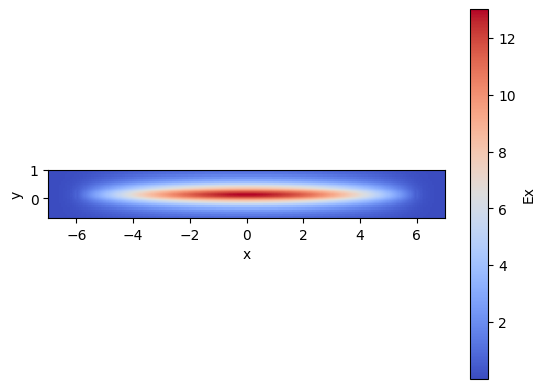

In [ ]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

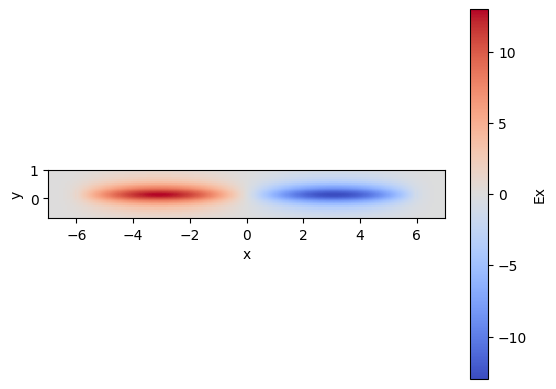

In [ ]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

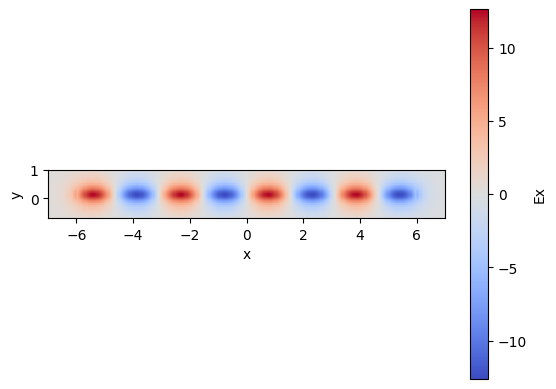

In [ ]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [ ]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794418495


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607254503  µm


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


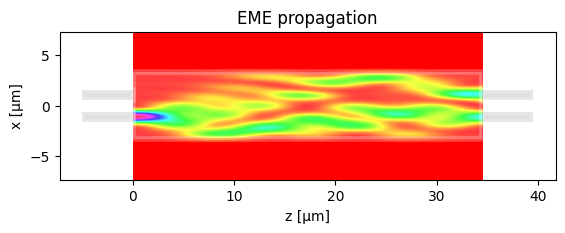

In [ ]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/674 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.8000
IO wg width 1.0000
IO wg width increment 0.9000
------------------------
Total power IN coupled 0.9969
Total OUT power: 0.9889
Excess loss [dB] =  0.0486
------------------------
Power over OUTs:  ['0.5101', '0.4788']
Ratio over OUTs ['0.5159', '0.4841']


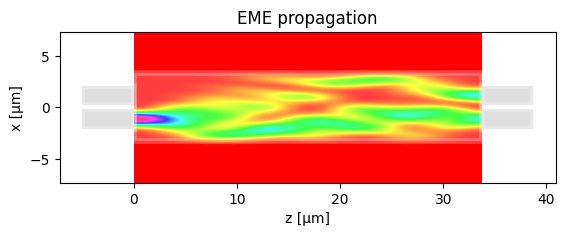

In [ ]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.8  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [ ]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.9 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725737  µm


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.9000
------------------------
Total power IN coupled 0.9959
Total OUT power: 0.9875
Excess loss [dB] =  0.0547
------------------------
Power over OUTs:  ['0.5034', '0.4841']
Ratio over OUTs ['0.5098', '0.4902']


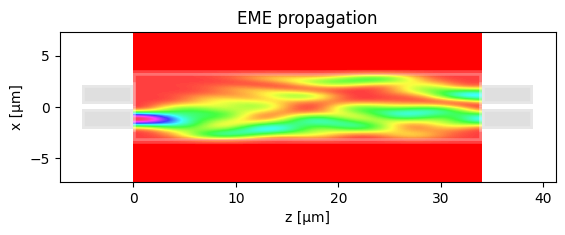

In [ ]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [ ]:
# LO.7: Diseño del acoplador de interferencia multimódo 1x4

# Para un acoplador 1x4, necesitamos asignar 4 guías de ondas de salida
# Espaciado típico de guías de ondas: ancho 1.2 µm + brecha 0.6 µm entre centros ≈ 1.8 µm por guía de ondas
# Para 4 guías de ondas: al menos 4*1.8 = 7.2 µm, pero usaremos un cuerpo MMI más grande


m_1x4 = MMI_EME()
m_1x4.MMI_width = 7.2     # Un poco más ancho ayuda a separar las 4 salidas
m_1x4.wg_width_dw = 0.5   # [STUDENT] Guías de acceso más anchas reducen pérdidas por dispersión
m_1x4.MMI_num_modes = 25  

# 1) Calcula los modos del cuerpo MMI
m_1x4.find_all_modes()

# 2) Obtener L_pi
L_pi_1x4 = m_1x4.get_L_pi()
print(f"L_pi = {L_pi_1x4:.2f} µm")

/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi = 81.55 µm


/home/jfgimloz/cifoi_practica2_lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)



--- Configuración del acoplador MMI 1x4 Optimizado ---


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/308 [00:00<?, ?it/s]

------- Pameters -------
MMI length 15.2897
MMI length increment 0.1000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 0.9841
Total OUT power: 0.9921
Excess loss [dB] =  0.0345
------------------------
Power over OUTs:  ['0.2345', '0.2615', '0.2616', '0.2345']
Ratio over OUTs ['0.2364', '0.2636', '0.2637', '0.2364']


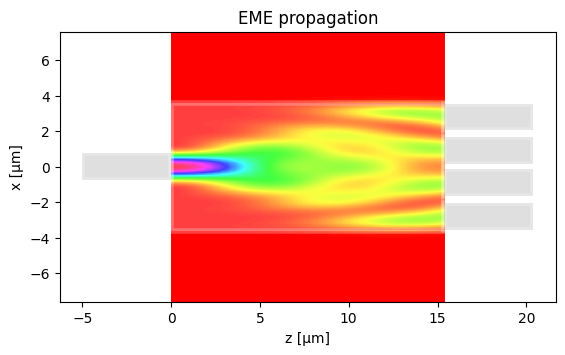

In [ ]:
# 3) Configura el acoplador MMI 1x4
m_1x4.n_IN = 1 
m_1x4.n_OUT = 4 

# Parámetro de ajuste para mejorar el equilibrio (Balance) entre salidas
dy = 0.1 # [STUDENT] Ajuste fino para la posición de las guías exteriores

# Posiciones para 4 guías de ondas de salida (distribuidas simétricamente)
W = m_1x4.MMI_width
pos_teoricas = np.array([-3/8, -1/8, 1/8, 3/8]) * W

# Aplicamos 'dy' para alejar ligeramente las guías exteriores y mejorar el acoplamiento
m_1x4.OUT_WVG_positions = pos_teoricas + np.array([-dy, 0, 0, dy])

# Entrada en el centro exacto para Interferencia Simétrica
m_1x4.IN_WVG_positions = np.array([0])

# 4) Longitud del acoplador MMI 1x4
# Para interferencia simétrica 1xN, la longitud es: L = (3 * L_pi) / (4 * N)
# Para N=4 -> L = (3/16) * L_pi
m_1x4.L_MMI = (3/16) * L_pi_1x4
m_1x4.dL_MMI = 0.1 # [STUDENT] Ajuste negativo para compensar el exceso de fase 

# Ejecuta la propagación
print("\n--- Configuración del acoplador MMI 1x4 Optimizado ---")
m_1x4.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

## Simulación para DEEP WAVEGUIDE


--- Simulando gap = 0.2 µm ---
2026-05-02 10:19:41.373 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.

--- Simulando gap = 0.4 µm ---
2026-05-02 10:19:41.384 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.

--- Simulando gap = 0.6 µm ---
2026-05-02 10:19:41.388 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_fa4c4babd472f540.npz.

--- Simulando gap = 0.8 µm ---
2026-05-02 10:19:41.392 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.

--- Simulando gap = 1.0 µm ---
2026-05-02 10:19:41.395 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.

--- Simulando gap = 1.2 µm ---
2026-05-02 10:19:41.397 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de78bc7bac7ad149.npz.

--- Simulando g

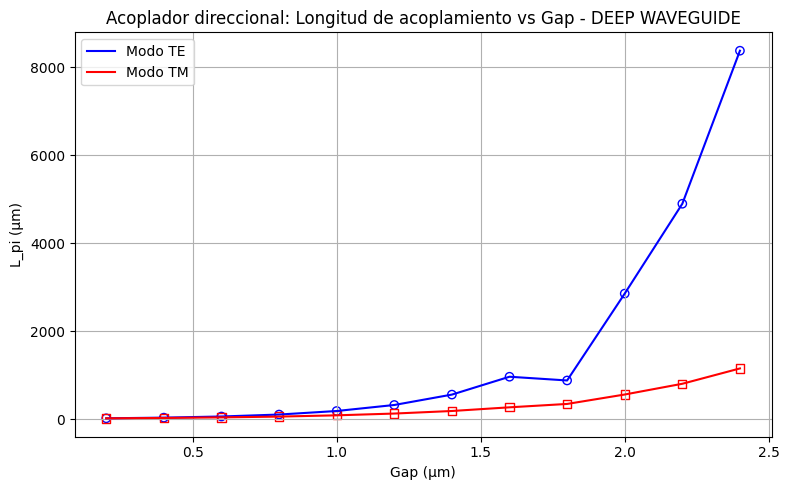

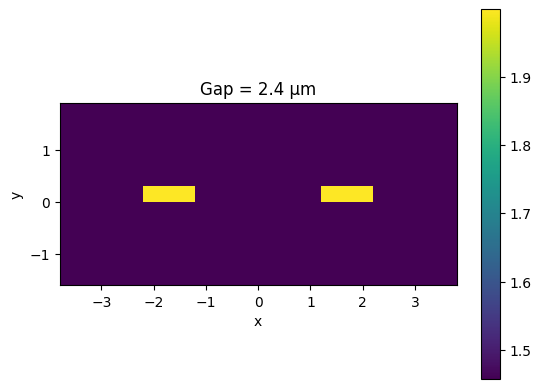

In [ ]:
# Valores de gap a simular: 0.2, 0.4, 0.6, ..., 2.4 µm
gaps_to_sweep = np.arange(0.2, 2.5, 0.2)  # en pasos de 0.2 µm

L_pi_TE_list = []  # Lista para guardar L_pi de TE
L_pi_TM_list = []  # Lista para guardar L_pi de TM

for gap_to_simulate in gaps_to_sweep:
    print(f"\n--- Simulando gap = {gap_to_simulate:.1f} µm ---")

    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=lambda_c, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=gap_to_simulate, # Conversión de µm a metros
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Fundamental TE (even/odd) y Fundamental TM (even/odd)
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    deep_neff = deep_dcoupler_cs.n_eff
    
    # Cálculo para Modo TE (Índices 0 y 1)
    L_pi_TE = 0.5 * lambda_c / (deep_neff[0].real - deep_neff[1].real)
    L_pi_TE_list.append(L_pi_TE)

    # Cálculo para Modo TM (Índices 2 y 3)
    L_pi_TM = 0.5 * lambda_c / (deep_neff[2].real - deep_neff[3].real)
    L_pi_TM_list.append(L_pi_TM)

# STUDENT. Plot goes here - L_pi vs Gap
plt.figure(figsize=(8, 5))

# Gráfica para TE
plt.scatter(gaps_to_sweep, L_pi_TE_list, edgecolors='blue', facecolors='none')
plt.plot(gaps_to_sweep, L_pi_TE_list, color='blue', label='Modo TE')

# Gráfica para TM
plt.scatter(gaps_to_sweep, L_pi_TM_list, edgecolors='red', facecolors='none', marker='s')
plt.plot(gaps_to_sweep, L_pi_TM_list, color='red', linestyle='-', label='Modo TM')

plt.xlabel("Gap (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador direccional: Longitud de acoplamiento vs Gap - DEEP WAVEGUIDE")
plt.grid()

# Añadimos la leyenda para identificar cada línea
plt.legend() 

plt.tight_layout()
plt.show()

# plot_index() solo del último gap simulado
deep_dcoupler_cs.plot_index()
plt.title(f"Gap = {gaps_to_sweep[-1]:.1f} µm")
plt.show()


## Simulación para SHADOW WAVEGUIDE


--- Simulando gap = 0.2 µm ---

--- Simulando gap = 0.4 µm ---
2026-05-02 13:57:13.622 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8c8eb63846dcafc2.npz.
2026-05-02 13:57:13.630 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9f55a49562c957ac.npz.

--- Simulando gap = 0.6 µm ---
2026-05-02 13:57:13.635 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_0aace39711989615.npz.

--- Simulando gap = 0.8 µm ---
2026-05-02 13:57:13.639 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_469dd463acb1cce2.npz.

--- Simulando gap = 1.0 µm ---
2026-05-02 13:57:13.640 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_12053cc304837a1c.npz.

--- Simulando gap = 1.2 µm ---
2026-05-02 13:57:13.645 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_64ce3e0adbff4874.npz.

--- Simulando g

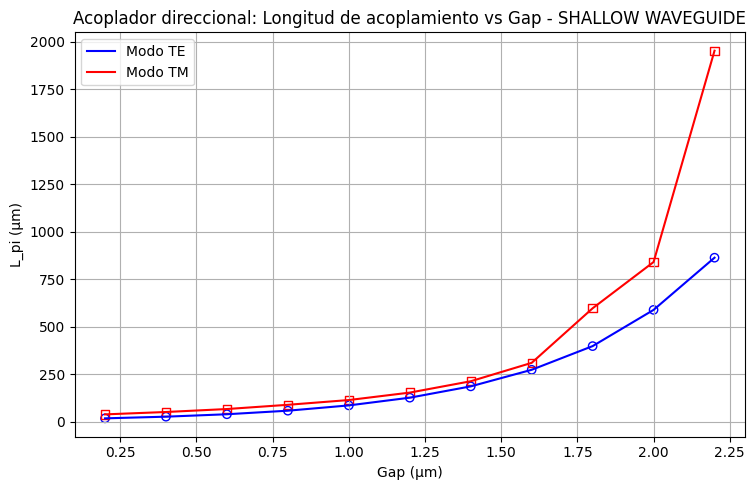

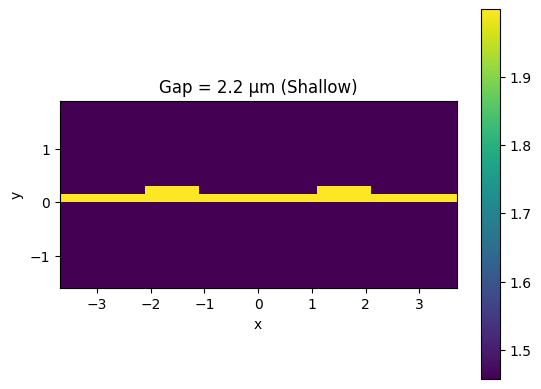

In [ ]:
# Valores de gap a simular: 0.2, 0.4, 0.6, ..., 2.4 µm
gaps_to_sweep = np.arange(0.2, 2.3, 0.2)  # en pasos de 0.2 µm

L_pi_TE_list = []  # Lista para guardar L_pi de TE
L_pi_TM_list = []  # Lista para guardar L_pi de TM

for gap_to_simulate in gaps_to_sweep:
    print(f"\n--- Simulando gap = {gap_to_simulate:.1f} µm ---")

    # Aunque la variable se llame "deep_", estamos simulando una "shallow"
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=lambda_c, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=gap_to_simulate, # Conversión de µm a metros
        slab_thickness=150 * nm, # ¡Ajustado a 150 nm para Shallow Waveguide!
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )

    deep_neff = deep_dcoupler_cs.n_eff
    
    # La forma de deep_neff es (4 modos,)
    # Modo TE (Supermodos Par e Impar en índices 0 y 1)
    L_pi_TE = 0.5 * lambda_c / (deep_neff[0].real - deep_neff[1].real)
    L_pi_TE_list.append(L_pi_TE)

    # Modo TM (Supermodos Par e Impar en índices 2 y 3)
    L_pi_TM = 0.5 * lambda_c / (deep_neff[2].real - deep_neff[3].real)
    L_pi_TM_list.append(L_pi_TM)

# STUDENT. Plot goes here - L_pi vs Gap
plt.figure(figsize=(9, 5))

# Gráfica para TE
plt.scatter(gaps_to_sweep, L_pi_TE_list, edgecolors='blue', facecolors='none')
plt.plot(gaps_to_sweep, L_pi_TE_list, color='blue', label='Modo TE')

# Gráfica para TM
plt.scatter(gaps_to_sweep, L_pi_TM_list, edgecolors='red', facecolors='none', marker='s')
plt.plot(gaps_to_sweep, L_pi_TM_list, color='red', linestyle='-', label='Modo TM')

plt.xlabel("Gap (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador direccional: Longitud de acoplamiento vs Gap - SHALLOW WAVEGUIDE")
plt.grid()
plt.legend()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# plot_index() solo del último gap simulado
deep_dcoupler_cs.plot_index()
plt.title(f"Gap = {gaps_to_sweep[-1]:.1f} µm (Shallow)")
plt.show()

### E2. Directional coupler wavelength dependence

## Simulación para DEEP WAVEGUIDE

2026-05-02 10:19:42.290 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_768317721804666d.npz.


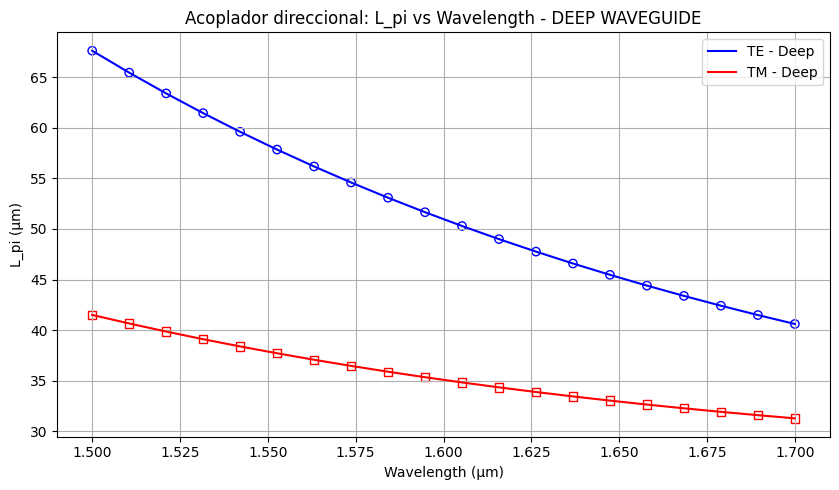

In [ ]:
# Definición del vector de longitudes de onda
wavelength = np.linspace(1.5, 1.7, 20)  # 1.5 a 1.7 µm

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, 
    core_width=(1.0, 1.0), 
    gap=600 * nm,
    slab_thickness=0 * nm, 
    core_material='sin', 
    clad_material='sio2', 
    core_thickness=300 * nm, 
    num_modes=4, 
    cache_path='.cache/', 
    precision='double',
    max_grid_scaling=1.5, 
    grid_resolution=20 
)

deep_neff = deep_dcoupler_cs.n_eff

# Cálculo de L_pi para TE (Modos 0 y 1)
# Usamos [:, 0] porque deep_neff es una matriz de (puntos_onda, num_modos)
L_pi_TE = 0.5 * wavelength / (deep_neff[:, 0].real - deep_neff[:, 1].real)

# Cálculo de L_pi para TM (Modos 2 y 3)
L_pi_TM = 0.5 * wavelength / (deep_neff[:, 2].real - deep_neff[:, 3].real)

plt.figure(figsize=(10, 5))

# Plot TE
plt.scatter(wavelength, L_pi_TE, edgecolors='blue', facecolors='none')
plt.plot(wavelength, L_pi_TE, color='blue', label='TE - Deep')

# Plot TM
plt.scatter(wavelength, L_pi_TM, edgecolors='red', facecolors='none', marker='s')
plt.plot(wavelength, L_pi_TM, color='red', linestyle='-', label='TM - Deep')

plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador direccional: L_pi vs Wavelength - DEEP WAVEGUIDE")
plt.grid()
plt.legend()
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Simulación para SHADOW WAVEGUIDE

2026-05-02 10:19:42.506 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_788e94ff4f3e4458.npz.


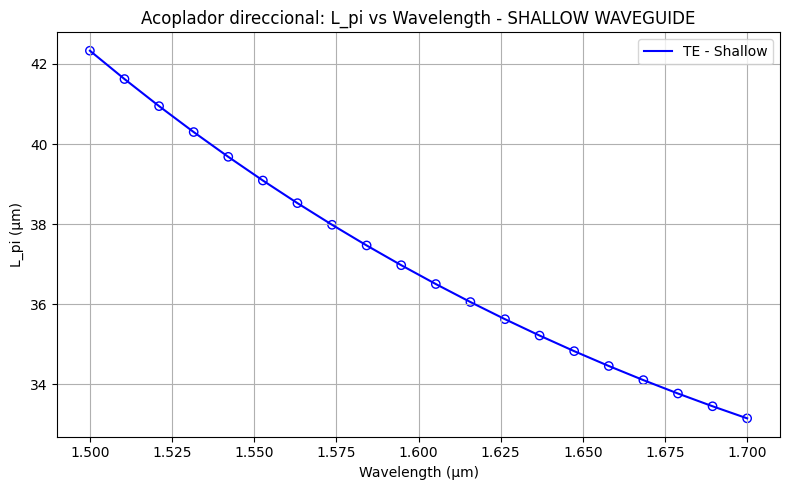

In [ ]:
# Definición del vector de longitudes de onda
wavelength = np.linspace(1.5, 1.7, 20)  # 1.5 a 1.7 µm

# Configuración para SHALLOW WAVEGUIDE
shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, 
    core_width=(1.0, 1.0), 
    gap=600 * nm,
    slab_thickness=150 * nm, # Shallow waveguide
    core_material='sin', 
    clad_material='sio2', 
    core_thickness=300 * nm, 
    num_modes=4, 
    cache_path='.cache/', 
    precision='double',
    max_grid_scaling=1.5, 
    grid_resolution=20 
)

shallow_neff = shallow_dcoupler_cs.n_eff

# Cálculo de L_pi para TE (Modos 0 y 1)
L_pi_TE = 0.5 * wavelength / (shallow_neff[:, 0].real - shallow_neff[:, 1].real)

# Cálculo de L_pi para TM (Modos 2 y 3)
L_pi_TM = 0.5 * wavelength / (shallow_neff[:, 2].real - shallow_neff[:, 3].real)

plt.figure(figsize=(8, 5))

# Plot TE - Shallow
plt.scatter(wavelength, L_pi_TE, edgecolors='blue', facecolors='none')
plt.plot(wavelength, L_pi_TE, color='blue', label='TE - Shallow')

# Plot TM - Shallow
#plt.scatter(wavelength, L_pi_TM, edgecolors='red', facecolors='none', marker='s')
#plt.plot(wavelength, L_pi_TM, color='red', linestyle='-', label='TM - Shallow')

plt.xlabel("Wavelength (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador direccional: L_pi vs Wavelength - SHALLOW WAVEGUIDE")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### E3. MMI coupler wavelength dependence

## Simulación para DEEP WAVEGUIDE

2026-05-02 10:19:42.647 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9a84ec86ddf79b0a.npz.


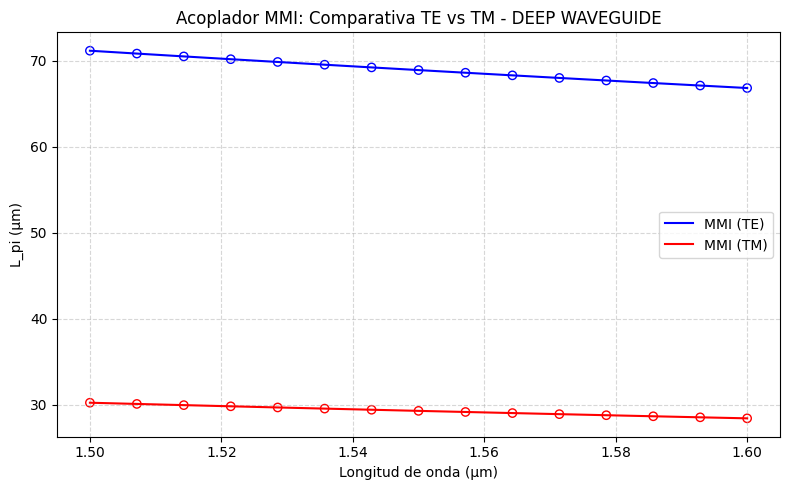

In [ ]:
mmi_body_w = 6.6 
lambda_c = np.linspace(1.5, 1.6, 15)

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

# --- CÁLCULO MODO TE ---
d_n_eff_te = mmi_body_waveguide.n_eff[:, 0].real - mmi_body_waveguide.n_eff[:, 1].real
L_pi_te = 0.5 * lambda_c / d_n_eff_te 

# --- CÁLCULO MODO TM ---
# En guías de 300nm de alto y 6.6um de ancho, los modos TM suelen 
# aparecer después de los primeros modos TE. Usamos índices 2 y 3.
index_tm0 = 2
index_tm1 = 3
d_n_eff_tm = mmi_body_waveguide.n_eff[:, index_tm0].real - mmi_body_waveguide.n_eff[:, index_tm1].real
L_pi_tm = 0.5 * lambda_c / d_n_eff_tm

# --- PLOT ---
plt.figure(figsize=(8, 5))

# Plot TE
plt.scatter(lambda_c, L_pi_te, edgecolors='blue', facecolors='none')
plt.plot(lambda_c, L_pi_te, color='blue', linestyle='-', label='MMI (TE)')

# Plot TM
plt.scatter(lambda_c, L_pi_tm, edgecolors='red', facecolors='none')
plt.plot(lambda_c, L_pi_tm, color='red', linestyle='-', label='MMI (TM)')

plt.xlabel("Longitud de onda (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador MMI: Comparativa TE vs TM - DEEP WAVEGUIDE")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Simulación para SHADOW WAVEGUIDE

2026-05-02 10:19:42.823 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ecd7726131724823.npz.


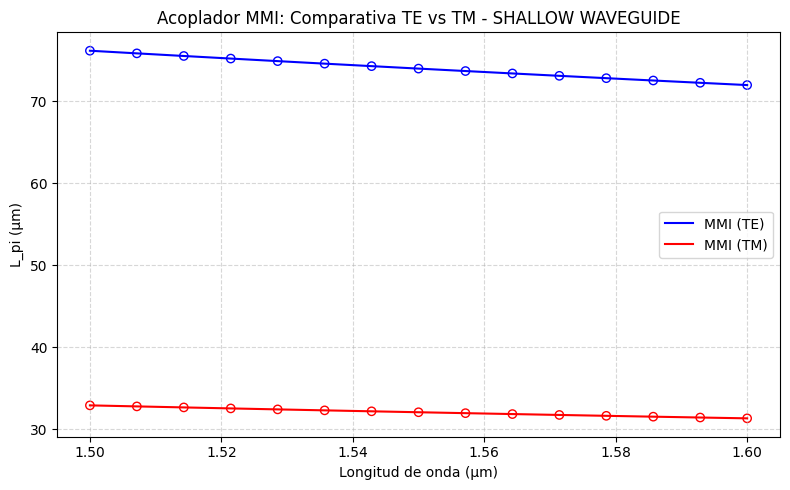

In [ ]:
lambda_c = np.linspace(1.5, 1.6, 15)

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

# --- CÁLCULO MODO TE ---
d_n_eff_te = mmi_body_waveguide.n_eff[:, 0].real - mmi_body_waveguide.n_eff[:, 1].real
L_pi_te = 0.5 * lambda_c / d_n_eff_te 

# --- CÁLCULO MODO TM ---
d_n_eff_tm = mmi_body_waveguide.n_eff[:, 2].real - mmi_body_waveguide.n_eff[:, 3].real
L_pi_tm = 0.5 * lambda_c / d_n_eff_tm

# --- PLOT ---
plt.figure(figsize=(8, 5))

# Plot TE
plt.scatter(lambda_c, L_pi_te, edgecolors='blue', facecolors='none')
plt.plot(lambda_c, L_pi_te, color='blue', linestyle='-', label='MMI (TE)')

# Plot TM
plt.scatter(lambda_c, L_pi_tm, edgecolors='red', facecolors='none')
plt.plot(lambda_c, L_pi_tm, color='red', linestyle='-', label='MMI (TM)')

plt.xlabel("Longitud de onda (µm)")
plt.ylabel("L_pi (µm)")
plt.title("Acoplador MMI: Comparativa TE vs TM - SHALLOW WAVEGUIDE")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### E4. MMI coupler body width dependence

## Simulación para DEEP WAVEGUIDE


--- Simulando ancho MMI = 5.0 µm ---
2026-05-03 12:39:53.028 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_750afcc7e2a92dbc.npz.

--- Simulando ancho MMI = 5.5 µm ---
2026-05-03 12:39:53.049 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cfaf3b95e6479b81.npz.

--- Simulando ancho MMI = 6.0 µm ---
2026-05-03 12:39:53.062 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7551f8975b22e6de.npz.

--- Simulando ancho MMI = 6.5 µm ---
2026-05-03 12:39:53.074 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d22c3e4b43a27194.npz.

--- Simulando ancho MMI = 7.0 µm ---
2026-05-03 12:39:53.085 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b60b2e67cbca1740.npz.

--- Simulando ancho MMI = 7.5 µm ---
2026-05-03 12:39:53.098 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7131944afff4b07f.npz.

--- Simulando ancho M


--- Simulando ancho MMI = 10.0 µm ---
2026-05-03 12:39:53.159 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0715b5214f4328e7.npz.


<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:63: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1225/2740540755.py:63: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$L_\pi$ (µm)")
/tmp/ipykernel_1225/2740540755.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Acoplador MMI: $L_\pi$ vs Ancho del cuerpo - DEEP WAVEGUIDE")


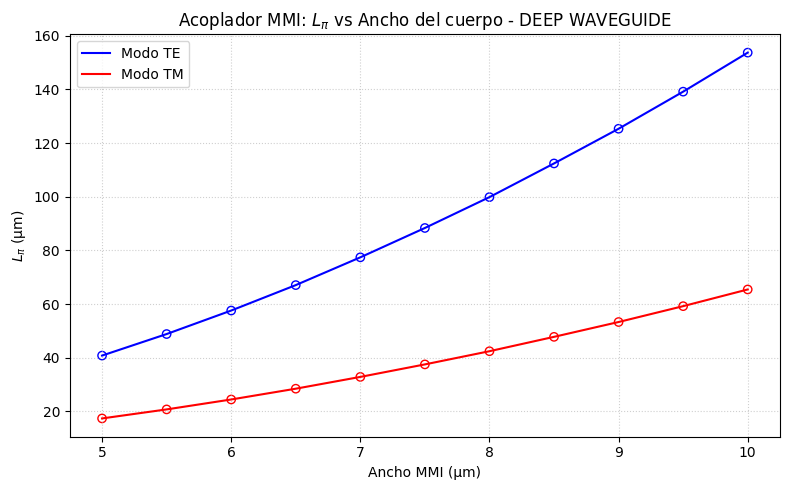

In [23]:
lambda_c = 1.55
mmi_widths_to_sweep = np.arange(5, 10.5, 0.5)  # en pasos de 0.5 µm

L_pi_te_list = []  # Lista para guardar L_pi del modo TE
L_pi_tm_list = []  # Lista para guardar L_pi del modo TM

for mmi_body_w in mmi_widths_to_sweep:
    print(f"\n--- Simulando ancho MMI = {mmi_body_w:.1f} µm ---")

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0 * nm, # Deep-etched waveguide
        # Materials
        core_material='sin', # Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Cache para ahorrar tiempo
        precision='double',
    )

    # --- CÁLCULO MODO TE ---
    # Usamos los índices 0 y 1 para los dos primeros modos TE
    d_n_eff_te = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real
    L_pi_te = 0.5 * lambda_c / d_n_eff_te
    L_pi_te_list.append(L_pi_te)

    # --- CÁLCULO MODO TM ---
    modos_tm_fraction = mmi_body_waveguide.fraction_tm
    modos_mmi_tm_indices = []

    # Buscamos los índices donde la fracción TE sea baja (es decir, que sean TM)
    #for i, f_tm in enumerate(modos_tm_fraction):
        #if f_tm < 0.5:  # Si es menor a 0.5, el modo es predominantemente TM
            #modos_mmi_tm_indices.append(i)

    #tm0 = modos_mmi_tm_indices[0]
    #tm1 = modos_mmi_tm_indices[1]

    #ESTO QUE ESTA COMENTADO NOS SERIA UTIL PARA CALCULAR LOS MODOS TM PRIMEROS

    d_n_eff_tm = mmi_body_waveguide.n_eff[2].real - mmi_body_waveguide.n_eff[3].real
    L_pi_tm = 0.5 * lambda_c / d_n_eff_tm
    L_pi_tm_list.append(L_pi_tm)

# --- GRÁFICA ---
plt.figure(figsize=(8, 5))

# Plot TE
plt.scatter(mmi_widths_to_sweep, L_pi_te_list, edgecolors='blue', facecolors='none')
plt.plot(mmi_widths_to_sweep, L_pi_te_list, label='Modo TE', color='blue')

# Plot TM
plt.scatter(mmi_widths_to_sweep, L_pi_tm_list, edgecolors='red', facecolors='none')
plt.plot(mmi_widths_to_sweep, L_pi_tm_list, label='Modo TM', color='red', linestyle='-')

plt.xlabel("Ancho MMI (µm)")
plt.ylabel("$L_\pi$ (µm)")
plt.title("Acoplador MMI: $L_\pi$ vs Ancho del cuerpo - DEEP WAVEGUIDE")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Simulación para SHADOW WAVEGUIDE


--- Simulando ancho MMI = 5.0 µm ---
2026-05-02 10:19:43.233 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_49e4659e7cd44e16.npz.

--- Simulando ancho MMI = 5.5 µm ---
2026-05-02 10:19:43.239 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_66f5f615be96f5a1.npz.

--- Simulando ancho MMI = 6.0 µm ---
2026-05-02 10:19:43.243 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8be1094f2e34de0e.npz.

--- Simulando ancho MMI = 6.5 µm ---
2026-05-02 10:19:43.246 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0d38a9666a5a6c2b.npz.

--- Simulando ancho MMI = 7.0 µm ---
2026-05-02 10:19:43.248 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_38632d1eb53ddcb7.npz.

--- Simulando ancho MMI = 7.5 µm ---
2026-05-02 10:19:43.251 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_26f5ced0e9153e0c.npz.

--- Simulando ancho M

<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1227/468857613.py:51: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$L_\pi$ (µm)")
/tmp/ipykernel_1227/468857613.py:52: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Acoplador MMI: $L_\pi$ vs Ancho del cuerpo - SHALLOW WAVEGUIDE")


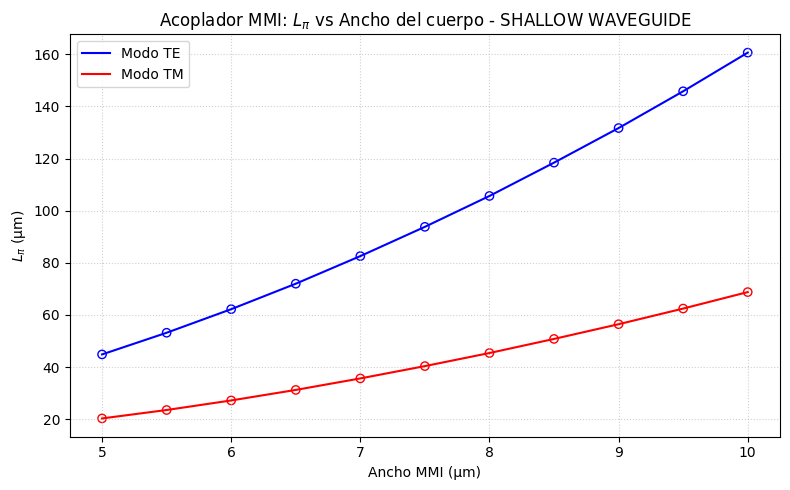

In [ ]:
lambda_c = 1.55
mmi_widths_to_sweep = np.arange(5, 10.5, 0.5)  # en pasos de 0.5 µm

L_pi_te_list = []  # Lista para guardar L_pi del modo TE
L_pi_tm_list = []  # Lista para guardar L_pi del modo TM

for mmi_body_w in mmi_widths_to_sweep:
    print(f"\n--- Simulando ancho MMI = {mmi_body_w:.1f} µm ---")

    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=150 * nm, # Deep-etched waveguide
        # Materials
        core_material='sin', # Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=15, # Targeted number of modes to find
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Cache para ahorrar tiempo
        precision='double',
    )

    # --- CÁLCULO MODO TE ---
    # Usamos los índices 0 y 1 para los dos primeros modos TE
    d_n_eff_te = mmi_body_waveguide.n_eff[0].real - mmi_body_waveguide.n_eff[1].real
    L_pi_te = 0.5 * lambda_c / d_n_eff_te
    L_pi_te_list.append(L_pi_te)

    # --- CÁLCULO MODO TM ---
    # Usamos los índices 2 y 3 para los dos primeros modos TM
    d_n_eff_tm = mmi_body_waveguide.n_eff[2].real - mmi_body_waveguide.n_eff[3].real
    L_pi_tm = 0.5 * lambda_c / d_n_eff_tm
    L_pi_tm_list.append(L_pi_tm)

# --- GRÁFICA ---
plt.figure(figsize=(8, 5))

# Plot TE
plt.scatter(mmi_widths_to_sweep, L_pi_te_list, edgecolors='blue', facecolors='none')
plt.plot(mmi_widths_to_sweep, L_pi_te_list, label='Modo TE', color='blue')

# Plot TM
plt.scatter(mmi_widths_to_sweep, L_pi_tm_list, edgecolors='red', facecolors='none')
plt.plot(mmi_widths_to_sweep, L_pi_tm_list, label='Modo TM', color='red', linestyle='-')

plt.xlabel("Ancho MMI (µm)")
plt.ylabel("$L_\pi$ (µm)")
plt.title("Acoplador MMI: $L_\pi$ vs Ancho del cuerpo - SHALLOW WAVEGUIDE")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points